# Penalty Field Experiments
Comparing **Value Iteration**, **Q-Learning**, **SARSA**, and **Dyna-Q** on a GridWorld with penalty fields.

**Environment:** 10×7 grid. A horizontal band of penalty cells (row 5, cols 1–5) cuts across the map,
leaving narrow clear corridors at column 0 and column 6.
Unlike cliffs, penalty fields **do not end the episode** — they just cost a large negative reward.
Algorithms must learn whether to pay the penalty for the shorter route or take the longer safe path around the band.

In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from helpers.env import SlipperyGridWorld, ACTIONS
from helpers.viz import (
    greedy_policy_from_V, evaluate,
    plot_env, plot_policy, plot_value_heatmap,
)
from helpers.rl import value_iteration, q_learning, sarsa
from helpers.dynaq import dyna_q

## Environment setup

In [ ]:
NUM_ROWS, NUM_COLS = 10, 7
START, GOAL = (0, 0), (9, 6)

# Horizontal penalty band: row 5, cols 1-5  (corridors at col 0 and col 6)
PENALTY_CELLS  = {(6, c) for c in range(1, 6)}
PENALTY_REWARD = -8.0

SLIP_PROB   = 0.1
STEP_REWARD = -1.0
GOAL_REWARD = 20.0
MAX_STEPS   = 200
GAMMA       = 0.99
SEED        = 42

def make_env(penalty_reward=PENALTY_REWARD):
    return SlipperyGridWorld(
        rows=NUM_ROWS, cols=NUM_COLS,
        start=START, goal=GOAL,
        slip_prob=SLIP_PROB,
        step_reward=STEP_REWARD,
        goal_reward=GOAL_REWARD,
        penalty_fields=PENALTY_CELLS,
        penalty_reward=penalty_reward,
        max_steps=MAX_STEPS,
        seed=SEED,
    )

env = make_env()

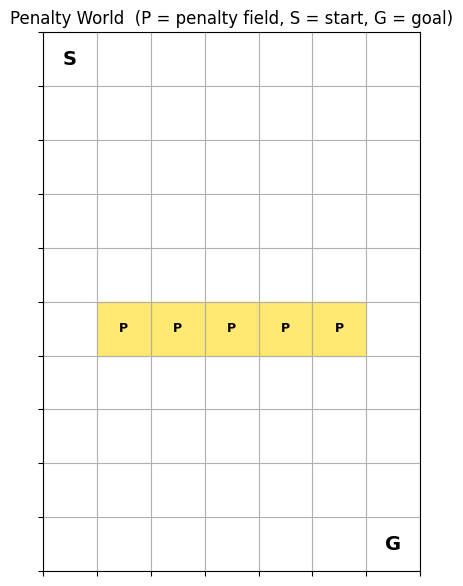

States: 70, Penalty cells: 5, Penalty reward: -8.0, Slip prob: 0.1


In [3]:
plot_env(env, title="Penalty World  (P = penalty field, S = start, G = goal)")
print(f"States: {env.num_states}, Penalty cells: {len(env.penalty_fields)}, "
      f"Penalty reward: {env.penalty_reward}, Slip prob: {env.slip_prob}")

## Value Iteration (model-based, exact)

In [4]:
env_vi = make_env()
V_vi, vi_iters = value_iteration(env_vi, max_iterations=500, gamma=GAMMA, threshold=1e-6)
pi_vi = greedy_policy_from_V(V_vi, env_vi, GAMMA)
metrics_vi = evaluate(env_vi, policy=pi_vi, n_episodes=500, seed=SEED)
print(f"Converged in {vi_iters} iterations")
print("Metrics:", metrics_vi)

Converged in 37 iterations
Metrics: {'avg_return': 4.022, 'std_return': 2.6694, 'success_rate': 1.0, 'avg_steps': 16.516}


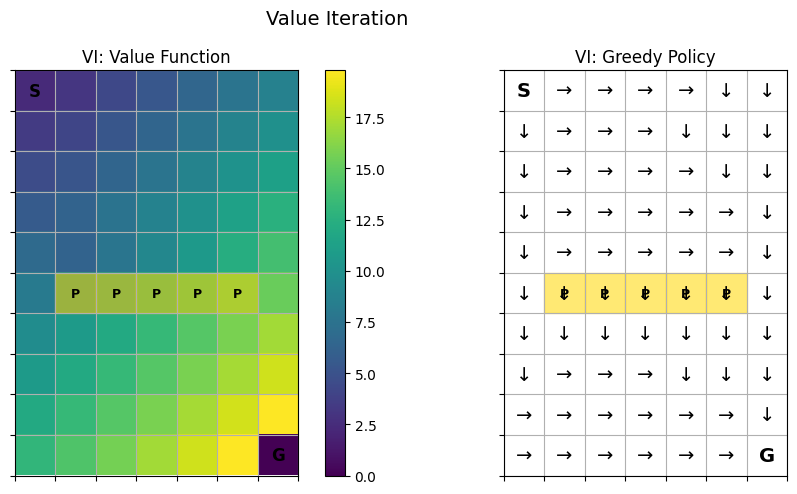

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_value_heatmap(env_vi, V_vi, title="VI: Value Function", ax=axes[0])
plot_policy(env_vi, pi_vi, title="VI: Greedy Policy", ax=axes[1])
plt.suptitle("Value Iteration", fontsize=14)
plt.tight_layout()
plt.savefig("penalty_vi.png", dpi=150)
plt.show()

## Q-Learning

In [6]:
N_EPISODES    = 15_000
ALPHA         = 0.2
EPSILON       = 0.8
EPSILON_MIN   = 0.01
EPSILON_DECAY = 0.9998

env_ql = make_env()
Q_ql, rewards_ql = q_learning(
    env_ql, n_episodes=N_EPISODES,
    alpha=ALPHA, gamma=GAMMA,
    epsilon=EPSILON, epsilon_min=EPSILON_MIN, epsilon_decay=EPSILON_DECAY,
    seed=SEED,
)
metrics_ql = evaluate(env_ql, Q=Q_ql, n_episodes=500, seed=SEED)
print("Q-Learning metrics:", metrics_ql)

Q-Learning metrics: {'avg_return': 3.56, 'std_return': 3.0526, 'success_rate': 1.0, 'avg_steps': 16.95}


## SARSA

In [7]:
env_sarsa = make_env()
Q_sarsa, rewards_sarsa = sarsa(
    env_sarsa, n_episodes=N_EPISODES,
    alpha=ALPHA, gamma=GAMMA,
    epsilon=EPSILON, epsilon_min=EPSILON_MIN, epsilon_decay=EPSILON_DECAY,
    seed=SEED,
)
metrics_sarsa = evaluate(env_sarsa, Q=Q_sarsa, n_episodes=500, seed=SEED)
print("SARSA metrics:", metrics_sarsa)

SARSA metrics: {'avg_return': 3.294, 'std_return': 3.1413, 'success_rate': 1.0, 'avg_steps': 17.314}


## Dyna-Q

In [14]:
N_PLANNING = 5

env_dynaq = make_env()
Q_dynaq, rewards_dynaq = dyna_q(
    env_dynaq, n_episodes=N_EPISODES,
    alpha=ALPHA, gamma=GAMMA,
    epsilon=EPSILON, epsilon_min=EPSILON_MIN, epsilon_decay=EPSILON_DECAY,
    n_planning_steps=N_PLANNING,
    seed=SEED,
)
metrics_dynaq = evaluate(env_dynaq, Q=Q_dynaq, n_episodes=500, seed=SEED)
print(f"Dyna-Q (n={N_PLANNING}) metrics:", metrics_dynaq)

Dyna-Q (n=5) metrics: {'avg_return': 3.164, 'std_return': 3.2189, 'success_rate': 1.0, 'avg_steps': 17.486}


## Comparison: Convergence curves

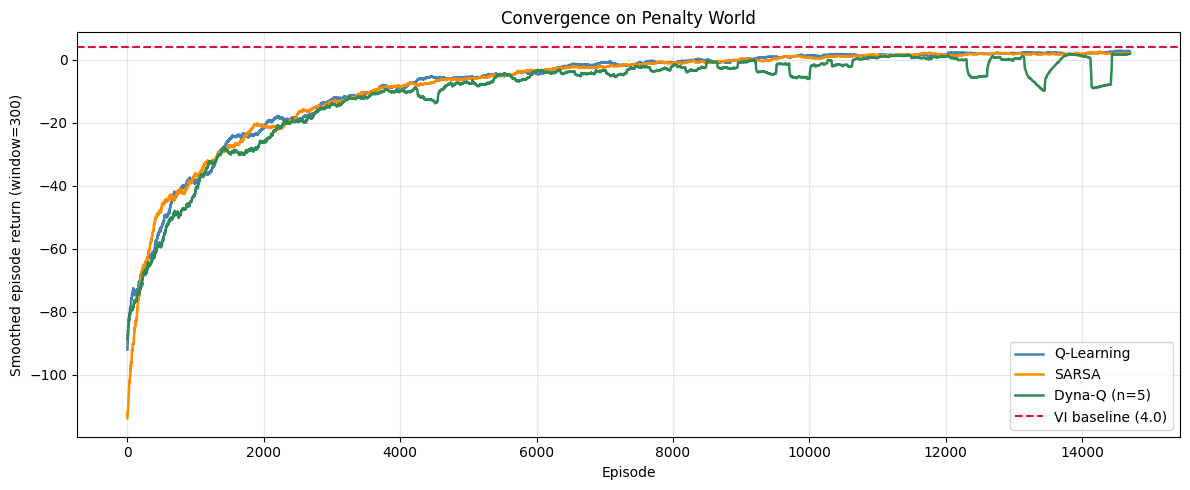

In [15]:
def smooth(x, w=300):
    return np.convolve(x, np.ones(w) / w, mode="valid")

fig, ax = plt.subplots(figsize=(12, 5))
for rewards, label, color in [
    (rewards_ql,    "Q-Learning",              "steelblue"),
    (rewards_sarsa, "SARSA",                   "darkorange"),
    (rewards_dynaq, f"Dyna-Q (n={N_PLANNING})", "seagreen"),
]:
    ax.plot(smooth(rewards), label=label, color=color, linewidth=1.8)

vi_ref = metrics_vi["avg_return"]
ax.axhline(vi_ref, color="crimson", linestyle="--",
           linewidth=1.5, label=f"VI baseline ({vi_ref:.1f})")
ax.set_xlabel("Episode")
ax.set_ylabel("Smoothed episode return (window=300)")
ax.set_title("Convergence on Penalty World")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("penalty_convergence.png", dpi=150)
plt.show()

## Comparison: Evaluation metrics

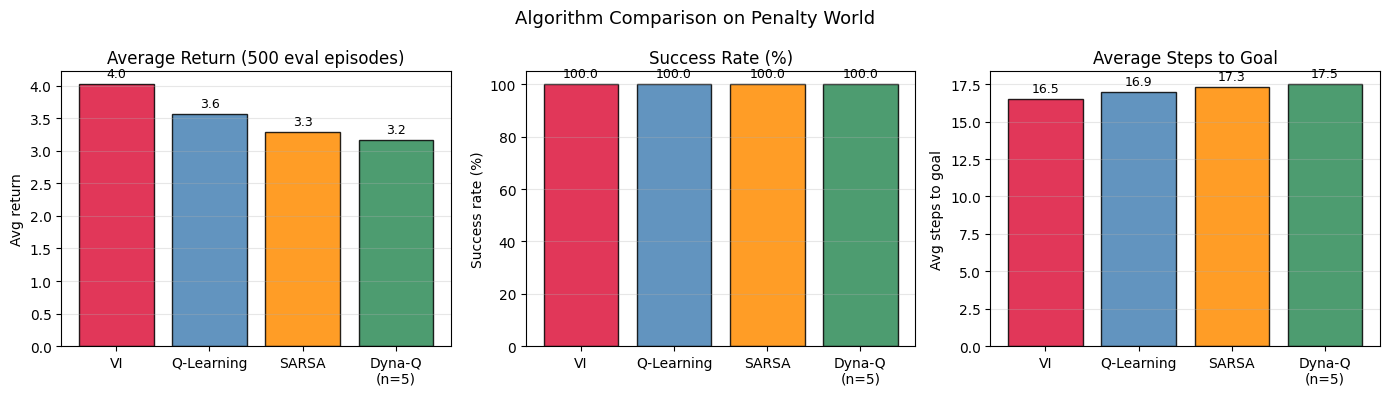

In [16]:
algo_names  = ["VI", "Q-Learning", "SARSA", f"Dyna-Q\n(n={N_PLANNING})"]
all_metrics = [metrics_vi, metrics_ql, metrics_sarsa, metrics_dynaq]
colors      = ["crimson", "steelblue", "darkorange", "seagreen"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, values, ylabel, title in zip(
    axes,
    [[m["avg_return"]         for m in all_metrics],
     [m["success_rate"] * 100 for m in all_metrics],
     [m["avg_steps"]          for m in all_metrics]],
    ["Avg return", "Success rate (%)", "Avg steps to goal"],
    ["Average Return (500 eval episodes)", "Success Rate (%)", "Average Steps to Goal"],
):
    bars = ax.bar(algo_names, values, color=colors, alpha=0.85, edgecolor="black")
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3)

plt.suptitle("Algorithm Comparison on Penalty World", fontsize=13)
plt.tight_layout()
plt.savefig("penalty_metrics.png", dpi=150)
plt.show()

## Policy and Value comparison (2×2)

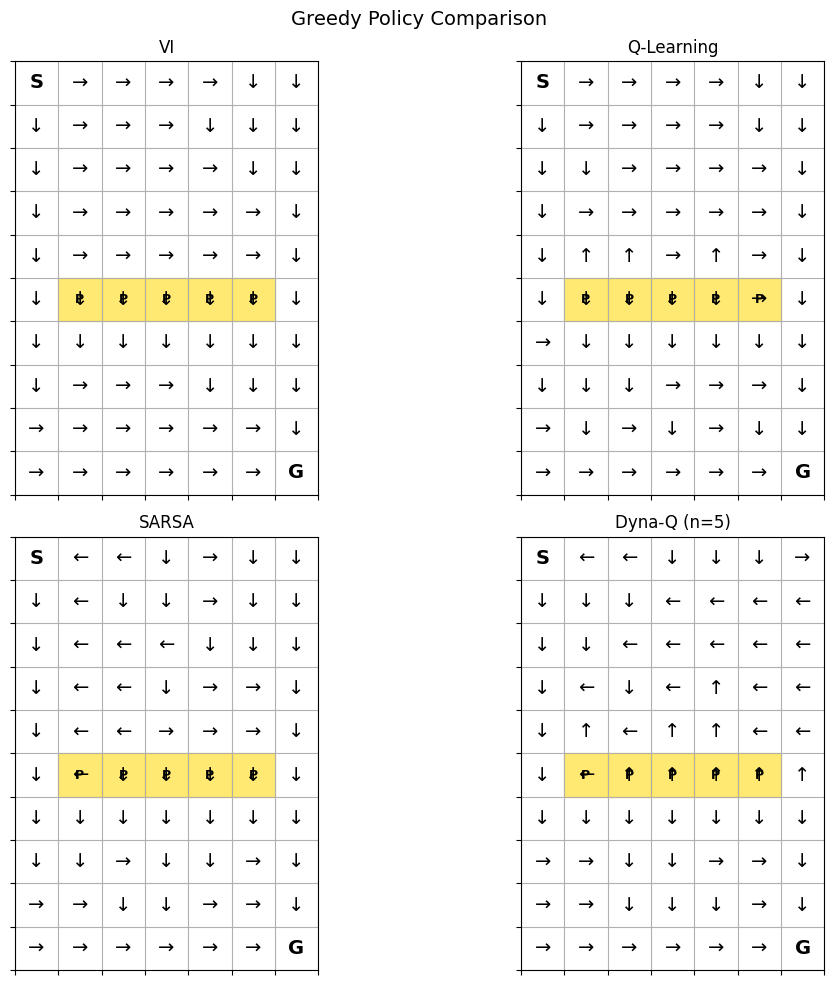

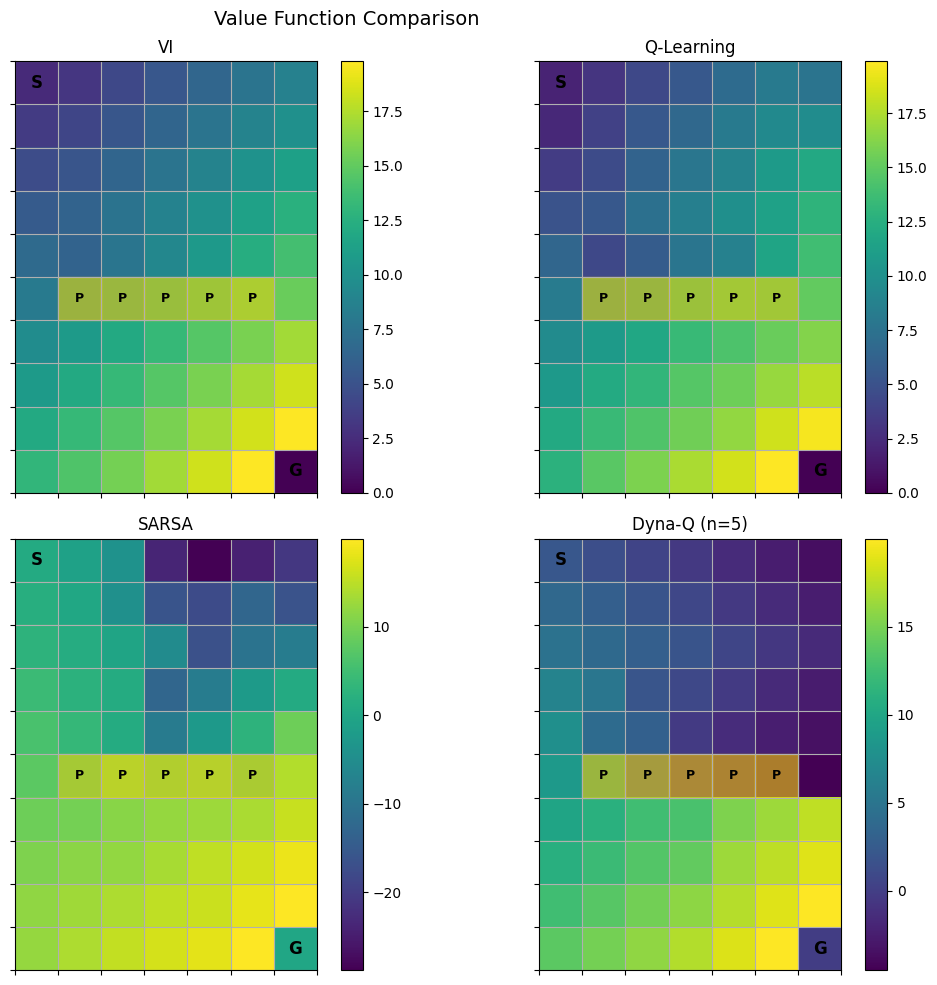

In [17]:
pi_ql    = np.argmax(Q_ql,    axis=1).astype(float)
pi_sarsa = np.argmax(Q_sarsa, axis=1).astype(float)
pi_dynaq = np.argmax(Q_dynaq, axis=1).astype(float)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, policy, env_ref, title in zip(
    axes.flat,
    [pi_vi,   pi_ql,   pi_sarsa, pi_dynaq],
    [env_vi,  env_ql,  env_sarsa, env_dynaq],
    ["VI", "Q-Learning", "SARSA", f"Dyna-Q (n={N_PLANNING})"],
):
    plot_policy(env_ref, policy, title=title, ax=ax)

plt.suptitle("Greedy Policy Comparison", fontsize=14)
plt.tight_layout()
plt.savefig("penalty_policies.png", dpi=150)
plt.show()

V_ql    = np.max(Q_ql,    axis=1)
V_sarsa = np.max(Q_sarsa, axis=1)
V_dynaq = np.max(Q_dynaq, axis=1)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, V, env_ref, title in zip(
    axes.flat,
    [V_vi,   V_ql,   V_sarsa,  V_dynaq],
    [env_vi, env_ql, env_sarsa, env_dynaq],
    ["VI", "Q-Learning", "SARSA", f"Dyna-Q (n={N_PLANNING})"],
):
    plot_value_heatmap(env_ref, V, title=title, ax=ax)

plt.suptitle("Value Function Comparison", fontsize=14)
plt.tight_layout()
plt.savefig("penalty_values.png", dpi=150)
plt.show()

## Penalty magnitude comparison across all algorithms
Train all four algorithms at each penalty level and compare how their policies respond.\n",
    "A **4×4 grid** (rows = penalty value, columns = algorithm) makes the behavioural differences\n",
    "immediately visible, followed by metric line plots showing the quantitative trade-off.

In [ ]:
PENALTY_VALUES = [-1, -4, -8, -16]

# results[p] = {"vi": (env, pi, V, metrics), "ql": ..., "sarsa": ..., "dynaq": ...}
penalty_results = {}

for p in PENALTY_VALUES:
    row = {}

    # VI
    e = make_env(penalty_reward=p)
    V, _ = value_iteration(e, max_iterations=500, gamma=GAMMA, threshold=1e-6)
    pi = greedy_policy_from_V(V, e, GAMMA)
    row["vi"] = (e, pi, V, evaluate(e, policy=pi, n_episodes=300, seed=SEED))

    # Q-Learning
    e = make_env(penalty_reward=p)
    Q, _ = q_learning(e, n_episodes=N_EPISODES, alpha=ALPHA, gamma=GAMMA,
                      epsilon=EPSILON, epsilon_min=EPSILON_MIN,
                      epsilon_decay=EPSILON_DECAY, seed=SEED)
    row["ql"] = (e, np.argmax(Q, axis=1).astype(float), np.max(Q, axis=1),
                 evaluate(e, Q=Q, n_episodes=300, seed=SEED))

    # SARSA
    e = make_env(penalty_reward=p)
    Q, _ = sarsa(e, n_episodes=N_EPISODES, alpha=ALPHA, gamma=GAMMA,
                 epsilon=EPSILON, epsilon_min=EPSILON_MIN,
                 epsilon_decay=EPSILON_DECAY, seed=SEED)
    row["sarsa"] = (e, np.argmax(Q, axis=1).astype(float), np.max(Q, axis=1),
                    evaluate(e, Q=Q, n_episodes=300, seed=SEED))

    # Dyna-Q
    e = make_env(penalty_reward=p)
    Q, _ = dyna_q(e, n_episodes=N_EPISODES, alpha=ALPHA, gamma=GAMMA,
                  epsilon=EPSILON, epsilon_min=EPSILON_MIN,
                  epsilon_decay=EPSILON_DECAY, n_planning_steps=N_PLANNING, seed=SEED)
    row["dynaq"] = (e, np.argmax(Q, axis=1).astype(float), np.max(Q, axis=1),
                    evaluate(e, Q=Q, n_episodes=300, seed=SEED))

    penalty_results[p] = row
    print(f"penalty={p:4.0f} | "
          + "  ".join(f"{k}: ret={v[3]['avg_return']:6.2f} suc={v[3]['success_rate']:.2f}"
                      for k, v in row.items()))

In [ ]:
ALGO_KEYS   = ["vi",         "ql",          "sarsa",   "dynaq"]
ALGO_LABELS = ["VI",         "Q-Learning",  "SARSA",   f"Dyna-Q (n={N_PLANNING})"]

# --- 4x4 policy grid: rows = penalty value, cols = algorithm ---
fig, axes = plt.subplots(len(PENALTY_VALUES), len(ALGO_KEYS),
                         figsize=(5 * len(ALGO_KEYS), 5 * len(PENALTY_VALUES)))

for row_idx, p in enumerate(PENALTY_VALUES):
    for col_idx, (key, label) in enumerate(zip(ALGO_KEYS, ALGO_LABELS)):
        ax = axes[row_idx, col_idx]
        e, pi, _, _ = penalty_results[p][key]
        col_title = label if row_idx == 0 else ""
        row_label = f"penalty={p}" if col_idx == 0 else ""
        plot_policy(e, pi, title=col_title, ax=ax)
        if row_label:
            ax.set_ylabel(row_label, fontsize=11)

plt.suptitle("Policy Comparison: all algorithms × penalty value", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("penalty_comparison_policies.png", dpi=130, bbox_inches="tight")
plt.show()

# --- 4x4 value heatmap grid ---
fig, axes = plt.subplots(len(PENALTY_VALUES), len(ALGO_KEYS),
                         figsize=(5 * len(ALGO_KEYS), 5 * len(PENALTY_VALUES)))

for row_idx, p in enumerate(PENALTY_VALUES):
    for col_idx, (key, label) in enumerate(zip(ALGO_KEYS, ALGO_LABELS)):
        ax = axes[row_idx, col_idx]
        e, _, V, _ = penalty_results[p][key]
        col_title = label if row_idx == 0 else ""
        row_label = f"penalty={p}" if col_idx == 0 else ""
        plot_value_heatmap(e, V, title=col_title, ax=ax)
        if row_label:
            ax.set_ylabel(row_label, fontsize=11)

plt.suptitle("Value Function Comparison: all algorithms × penalty value", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("penalty_comparison_values.png", dpi=130, bbox_inches="tight")
plt.show()

In [ ]:
# --- Metric line plots: avg_return and avg_steps vs penalty value per algorithm ---
ALGO_COLORS = {"vi": "crimson", "ql": "steelblue", "sarsa": "darkorange", "dynaq": "seagreen"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for key, label in zip(ALGO_KEYS, ALGO_LABELS):
    returns = [penalty_results[p][key][3]["avg_return"] for p in PENALTY_VALUES]
    steps   = [penalty_results[p][key][3]["avg_steps"]  for p in PENALTY_VALUES]
    axes[0].plot(PENALTY_VALUES, returns, marker="o", label=label,
                 color=ALGO_COLORS[key], linewidth=2)
    axes[1].plot(PENALTY_VALUES, steps,   marker="o", label=label,
                 color=ALGO_COLORS[key], linewidth=2)

for ax, ylabel, title in zip(
    axes,
    ["Avg return (300 eval episodes)", "Avg steps to goal"],
    ["Average Return vs Penalty Value", "Average Steps vs Penalty Value"],
):
    ax.set_xlabel("Penalty reward")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.invert_xaxis()   # most negative on the right → severity increases left→right

plt.suptitle("How penalty magnitude affects each algorithm", fontsize=13)
plt.tight_layout()
plt.savefig("penalty_metrics_vs_penalty.png", dpi=150)
plt.show()

## Conclusions

### Penalty fields vs cliffs
- Penalty fields raise the cost of a path segment without terminating the episode.
  The agent is free to traverse them — the question is whether it's worth it.
- This creates a genuine **route trade-off**: short paths cut through the penalty zone;
  longer detour paths avoid it entirely.

### Value Iteration
- Computes the exact optimal policy by weighing every possible path cost through the
  Bellman equations. Its value function shows a clear drop around the penalty band.
- Acts as the performance ceiling at every penalty level.

### Q-Learning vs SARSA with penalties
- **Q-Learning** (off-policy) bootstraps from the greedy next action, so it correctly
  evaluates the penalty-free value of the best available action at each step.
  It typically converges to the same route as VI.
- **SARSA** (on-policy) evaluates the *actually taken* action (including exploratory moves),
  so during training it experiences penalty cells more frequently and learns to be more
  cautious near the band — sometimes choosing the longer safe path even after convergence.
- With `slip_prob > 0` both algorithms must account for the risk of being pushed into the
  penalty zone; SARSA's on-policy update incorporates this risk more directly.

### Dyna-Q
- Planning steps accelerate discovery of the safe corridor around the penalty band.
  The model quickly propagates penalty information backward without additional real experience.
  Converges faster than Q-Learning and SARSA at every penalty level.

### Penalty magnitude comparison (all algorithms × all penalty values)
- At **low penalty** all algorithms converge to the same short path cutting through the band —
  the detour costs more in step penalties than the penalty zone itself.
- As penalty increases, algorithms diverge: VI and Q-Learning switch to the safe corridor
  at a well-defined threshold; SARSA often switches earlier due to its on-policy updates.
- The **4×4 policy grid** makes the switching point visible: look for the row where arrows
  near row 5 change from pointing down (through penalties) to pointing sideways (around them).
- The **metric line plots** show how avg_return and avg_steps evolve with penalty severity.
  A sharp drop in return signals the penalty is high enough to be unavoidable even on detour
  paths; a rise in avg_steps signals the agent switched to a longer route.